In [7045]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import json

# Import parameters

In [7046]:
frequncy_filtered_amp_df = pd.read_csv('data/parameters/handflapping_fft_simulation_parameters.csv')
accel_mag_parameters = pd.read_csv('data/parameters/handflapping_accel_mag_parameters.csv', index_col=0)

with open("data/parameters/handflapping_episode_parameters.json", "r") as infile:
    parameters = json.load(infile)

# Set parameters

In [7047]:
sample_rate = 50  # samples per second
num_seconds = 120  # Number of seconds

## Generate parameters

### Generate paramters for episodes

In [7048]:
n_episodes = num_seconds / 60 * np.random.normal(parameters['n_episode_per_minute_mean'], parameters['n_episode_per_minute_std'])
n_episodes = int(np.rint(n_episodes))
print("number of episodes:", n_episodes)

number of episodes: 4


In [7049]:
episode_durations = []
for i in range(n_episodes):
    episode_duration = np.random.normal(
        parameters['episode_duration_log10_mean'],
        parameters['episode_duration_log10_std'])
    episode_duration = 10 ** episode_duration 
    episode_durations.append(episode_duration)  

print("Episode durations in seconds:", episode_durations)
episode_durations = np.array(episode_durations)
episode_segment_lengths = (episode_durations * sample_rate).astype(int)
episode_segment_lengths
print("Episode durations in samples:", episode_segment_lengths)

Episode durations in seconds: [1.1537875026376283, 11.517845822106391, 2.5896281117304887, 0.9689561491691342]
Episode durations in samples: [ 57 575 129  48]


### Generate paramters for acceleration magnitude scales

In [7050]:
accel_mag_parameters

,episode,mean_accel_mag,min_accel_mag,max_accel_mag,range_accel_mag,mean_to_min_accel_mag,max_to_mean_accel_mag,mean_accel_mag_log10,min_accel_mag_log10,max_accel_mag_log10,range_accel_mag_log10,mean_to_min_accel_mag_log10,max_to_mean_accel_mag_log10
count,414.000000,414.000000,414.000000,414.000000,414.000000,414.000000,414.000000,414.000000,414.000000,414.000000,414.000000,414.000000,414.000000
mean,207.500000,1.116460,0.750633,1.699940,0.949307,0.365827,0.583480,0.045835,-0.147966,0.213300,-0.196443,-0.614975,-0.418810
std,119.655756,0.115223,0.211575,0.503958,0.655506,0.263168,0.417462,0.040479,0.156720,0.120133,0.492488,0.482956,0.513978
min,1.000000,0.937573,0.144274,1.038431,0.028527,0.012935,0.014422,-0.027995,-0.840811,0.016378,-1.544744,-1.888245,-1.840963
25%,104.250000,1.041017,0.624519,1.402649,0.541735,0.170903,0.321848,0.017458,-0.204454,0.146949,-0.266214,-0.767250,-0.492350
50%,207.500000,1.092263,0.773568,1.637651,0.856708,0.318108,0.534717,0.038327,-0.111502,0.214221,-0.067168,-0.497429,-0.271876
75%,310.750000,1.147639,0.944173,1.889215,1.265884,0.514216,0.749652,0.059805,-0.024948,0.276281,0.102393,-0.288862,-0.125140
max,414.000000,1.787953,1.022939,3.717011,3.185450,1.317549,2.407127,0.252356,0.009850,0.570194,0.503171,0.119767,0.381499


In [7051]:
min_accel_mag = accel_mag_parameters.loc['min', 'min_accel_mag']
max_accel_mag = accel_mag_parameters.loc['max', 'max_accel_mag']
print(min_accel_mag, max_accel_mag)

0.1442744060594489 3.717011361834356


In [7052]:
# def generate_accel_mag_range(df=accel_mag_parameters):

#     mean_accel_mag_mean = df.loc['mean', 'mean_accel_mag']
#     mean_accel_mag_std = df.loc['std', 'mean_accel_mag']
#     mean_accel_mag = np.random.normal(mean_accel_mag_mean, mean_accel_mag_std)

#     mean_to_min = 10 ** np.random.normal(df.loc['mean', 'mean_to_min_accel_mag_log10'], df.loc['std', 'mean_to_min_accel_mag_log10'])
#     max_to_mean = 10 ** np.random.normal(df.loc['mean', 'max_to_mean_accel_mag_log10'], df.loc['std', 'max_to_mean_accel_mag_log10'])

#     if mean_to_min > df.loc['max', 'mean_to_min_accel_mag']:
#         mean_to_min = df.loc['max', 'mean_to_min_accel_mag']
#     elif mean_to_min < df.loc['min', 'mean_to_min_accel_mag']:
#         mean_to_min = df.loc['min', 'mean_to_min_accel_mag']

#     if max_to_mean > df.loc['max', 'max_to_mean_accel_mag']:
#         max_to_mean = df.loc['max', 'max_to_mean_accel_mag']
#     elif max_to_mean < df.loc['min', 'max_to_mean_accel_mag']:
#         max_to_mean = df.loc['min', 'max_to_mean_accel_mag']

#     min_accel_mag = accel_mag_parameters.loc['min', 'min_accel_mag']
#     max_accel_mag = accel_mag_parameters.loc['max', 'max_accel_mag']
    
#     min_accel_mag_new = max((mean_accel_mag  - mean_to_min), min_accel_mag)
#     max_accel_mag_new = min((mean_accel_mag + max_to_mean), max_accel_mag)

#     return float(min_accel_mag_new), float(max_accel_mag_new)

In [7053]:
# def generate_accel_mag_range():
#     min_accel_mag = accel_mag_parameters.loc['mean', 'min_accel_mag']
#     max_accel_mag = accel_mag_parameters.loc['mean', 'max_accel_mag']
#     return (min_accel_mag, max_accel_mag)
    

In [7054]:
def generate_accel_mag_range():
    min_accel_mag = accel_mag_parameters.loc['min', 'min_accel_mag']
    max_accel_mag = accel_mag_parameters.loc['max', 'max_accel_mag']
    return (min_accel_mag, max_accel_mag)

In [7055]:
negative_scaling_at_mean = np.absolute(
    (accel_mag_parameters.loc['mean', 'min_accel_mag'] - accel_mag_parameters.loc['mean', 'mean_accel_mag']) /
    (accel_mag_parameters.loc['mean', 'max_accel_mag'] - accel_mag_parameters.loc['mean', 'mean_accel_mag'])
    )

negative_scaling_at_median = np.absolute(
    (accel_mag_parameters.loc['50%', 'min_accel_mag'] - accel_mag_parameters.loc['50%', 'mean_accel_mag']) /
    (accel_mag_parameters.loc['50%', 'max_accel_mag'] - accel_mag_parameters.loc['50%', 'mean_accel_mag'])
    )

negative_scaling_at_25_perc = np.absolute(
    (accel_mag_parameters.loc['25%', 'min_accel_mag'] - accel_mag_parameters.loc['25%', 'mean_accel_mag']) /
    (accel_mag_parameters.loc['25%', 'max_accel_mag'] - accel_mag_parameters.loc['25%', 'mean_accel_mag'])
    )

negative_scaling_at_75_perc = np.absolute(
    (accel_mag_parameters.loc['75%', 'min_accel_mag'] - accel_mag_parameters.loc['75%', 'mean_accel_mag']) /
    (accel_mag_parameters.loc['75%', 'max_accel_mag'] - accel_mag_parameters.loc['75%', 'mean_accel_mag'])
    )

negative_scaling_at_100_perc = np.absolute(
    (accel_mag_parameters.loc['max', 'min_accel_mag'] - accel_mag_parameters.loc['max', 'mean_accel_mag']) /
    (accel_mag_parameters.loc['max', 'max_accel_mag'] - accel_mag_parameters.loc['max', 'mean_accel_mag'])
    )

negative_scaling = negative_scaling_at_median

In [7056]:
# def generate_accel_mag_range():
#     min_accel_mag = np.random.uniform(
#         accel_mag_parameters.loc['25%', 'min_accel_mag'],
#         (accel_mag_parameters.loc['75%', 'min_accel_mag'] / 2)
#     )
    
#     max_accel_mag = np.random.normal(
#         accel_mag_parameters.loc['25%', 'max_accel_mag'],
#         (accel_mag_parameters.loc['75%', 'max_accel_mag'] / 2)
#     )
#     return (min_accel_mag, max_accel_mag)
    

# Generate time array

In [7057]:
time_array = np.linspace(0, num_seconds, sample_rate * num_seconds, endpoint=False)

# Generate hanflapping signal

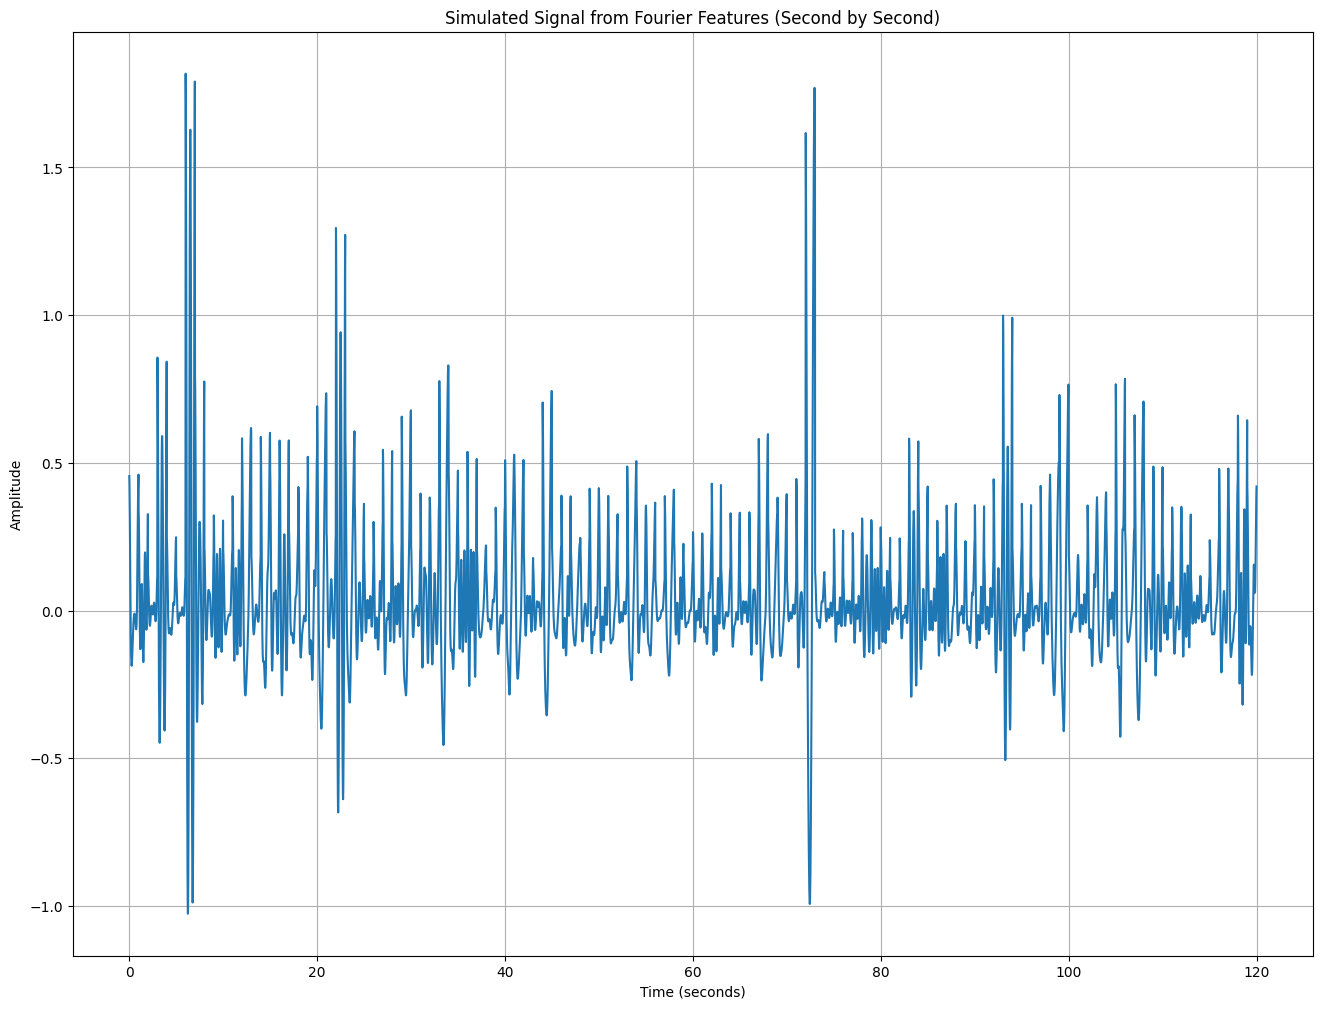

In [7058]:
# Step 1: Convert log10 amplitudes back to linear scale
frequency_hz = np.array([1, 2, 3])
amplitudes_log10_mean = frequncy_filtered_amp_df['amp_log10_filtered_mean'][1:4].values
amplitudes_log10_std = frequncy_filtered_amp_df['amp_log10_filtered_std'][1:4].values

# frequency_hz = np.array([0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24])
# amplitudes_log10_mean = frequncy_filtered_amp_df['amp_log10_filtered_mean'].values
# amplitudes_log10_std = frequncy_filtered_amp_df['amp_log10_filtered_std'].values

# Step 2: Set parameters for time and sample rate

t_per_second = np.linspace(0, 1, sample_rate, endpoint=False)  # Time vector for 1 second

# Step 3: Initialize the full signal
full_signal = []

# Step 4: Generate signal second by second
# Initial random phases for each frequency
phases = np.random.uniform(0, 2 * np.pi, len(frequency_hz))

for sec in range(num_seconds):
    signal = np.zeros_like(t_per_second)

    amplitudes_log10 = np.random.normal(amplitudes_log10_mean, amplitudes_log10_std)
    amplitudes = 10 ** amplitudes_log10

    for i, freq in enumerate(frequency_hz):
        amplitude = amplitudes[i]
        phase = phases[i]
        signal += amplitude * np.sin(2 * np.pi * freq * t_per_second + phase)
        
        # Update phase for the next second (shift by 2 * pi * frequency * 1 second)
        phases[i] += 2 * np.pi * freq

    full_signal.extend(signal)  # Append the signal for this second to the full signal

# Rescale to the desired range
full_signal_range = np.max(full_signal) - np.min(full_signal)
min_signal, max_signal = generate_accel_mag_range()
# min_signal, max_signal = -1, 1

# Apply rescaling
full_signal = min_signal + (max_signal - min_signal) / full_signal_range * (full_signal - np.min(full_signal))
full_signal = full_signal - np.mean(full_signal)  # Center the signal around 0

# Scale the positive and negative parts differently
positive_scaling = 1  # Steeper for positive waves
negative_scaling = negative_scaling
 # Shallower for negative waves
full_signal = np.where(full_signal > 0, full_signal * positive_scaling, full_signal * negative_scaling)

# Step 5: Plot the resulting full signal
plt.figure(figsize=(16, 12))  # Set the figure size here
plt.plot(time_array, full_signal)
plt.title('Simulated Signal from Fourier Features (Second by Second)')
plt.xlabel('Time (seconds)')
plt.ylabel('Amplitude')
plt.grid(True)
plt.show()

# Generate steps

Segment from 2107 to 2164
Segment from 5328 to 5903
Segment from 3338 to 3467
Segment from 1953 to 2001


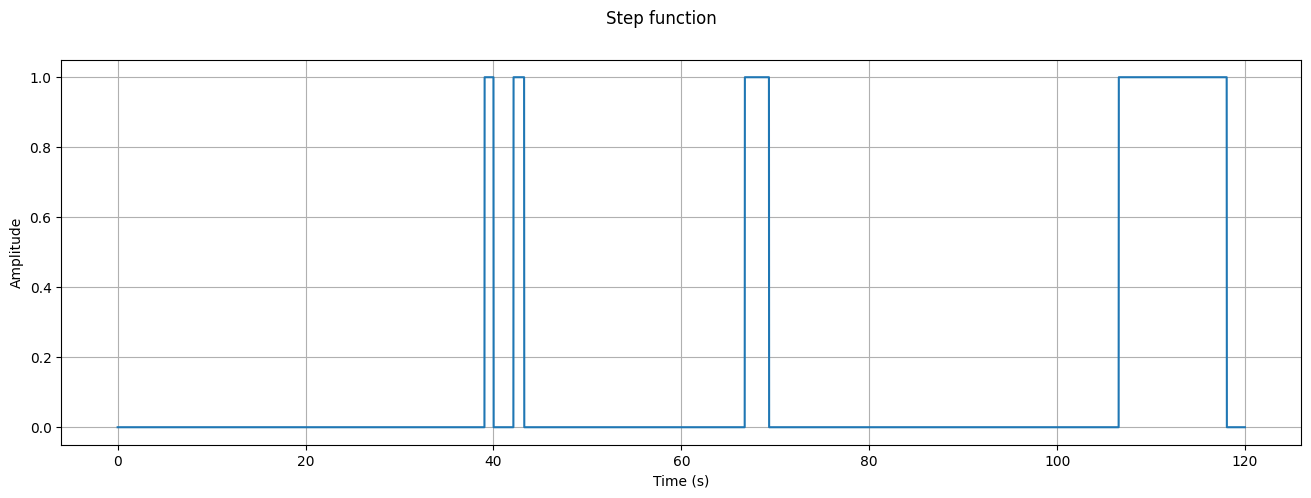

In [7059]:
# Step 1: Initialize the parameters
steps = np.zeros_like(time_array)
n_steps = n_episodes
step_value = 1
segment_lengths = episode_segment_lengths

# Step 2: Ensure non-overlapping indices
available_positions = np.arange(len(steps))  # All positions are initially available
start_indices = []

# Step 3: Assign non-overlapping start indices
for length in segment_lengths:
    # Ensure enough space remains to fit the segment
    possible_starts = available_positions[available_positions <= len(steps) - length]
    start_idx = np.random.choice(possible_starts)
    start_indices.append(start_idx)

    # Mark the positions of the segment as used
    end_idx = start_idx + length
    print(f"Segment from {start_idx} to {end_idx}")
    available_positions = np.setdiff1d(available_positions, np.arange(start_idx, end_idx))

# Step 4: Assign step values based on the selected indices
for i, start_idx in enumerate(start_indices):
    end_idx = start_idx + segment_lengths[i]
    steps[start_idx:end_idx] = step_value

# Step 5: Plot the step function
plt.figure(figsize=(16, 5))
plt.plot(time_array, steps)
plt.suptitle("Step function")
plt.xlabel("Time (s)")
plt.ylabel("Amplitude")
plt.grid(True)
plt.show()

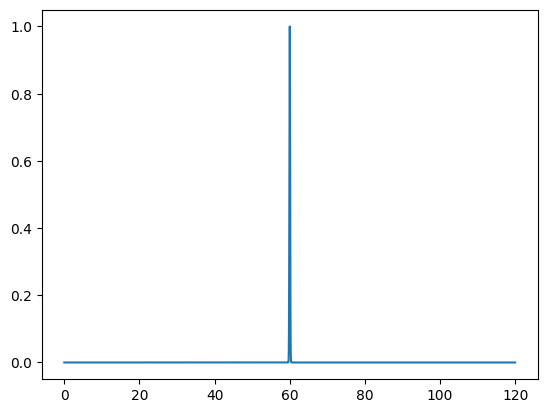

In [7060]:
# a gaussian g
t0 = num_seconds/2
sigma = 0.1
g = np.exp(-((time_array-t0)**2)/(2*sigma**2))
plt.plot(time_array, g)

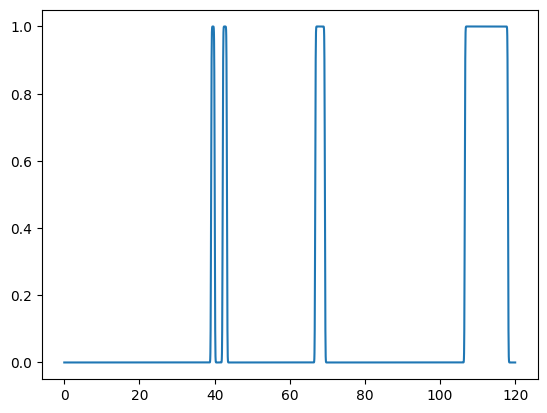

In [7061]:
# convolution of g and s
c = np.convolve(steps, g/10, mode='same')
c = c / max(c)
plt.plot(time_array, c)

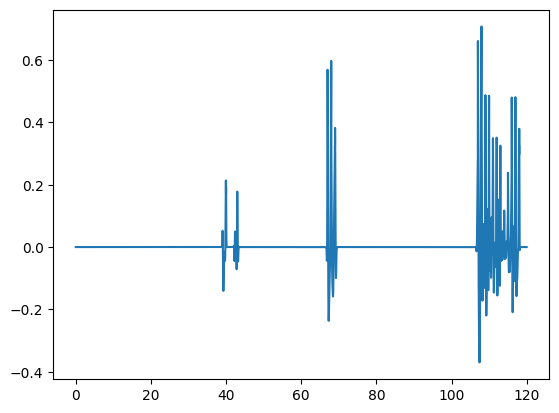

In [7062]:
final_signal = c * full_signal 

plt.plot(time_array, c * final_signal)

In [7063]:
a = np.linspace(-1, 1, 20)
np.where(a > 0, a * 2, a)

array([-1.        , -0.89473684, -0.78947368, -0.68421053, -0.57894737,
       -0.47368421, -0.36842105, -0.26315789, -0.15789474, -0.05263158,
        0.10526316,  0.31578947,  0.52631579,  0.73684211,  0.94736842,
        1.15789474,  1.36842105,  1.57894737,  1.78947368,  2.        ])

# Generate noise

In [7064]:
def generate_filtered_noise(length, noise_std=0.2, alpha=0.9, beta=0.01):
    # Step 1: Generate Gaussian noise with mean 0 and standard deviation `noise_std`
    noise = np.random.normal(0, noise_std, length)
    
    # Step 2: Apply a low-pass filter
    filtered_noise = np.zeros_like(noise)
    filtered_noise[0] = 0  # Initialize the first value
    for i in range(1, length):
        filtered_noise[i] = alpha * filtered_noise[i-1] + beta * noise[i]
    
    return filtered_noise

noise = generate_filtered_noise(len(full_signal))

In [7065]:
final_signal = c * full_signal + noise + 1

In [7066]:
# Generate detected array
detected = np.repeat(False, len(time_array))
detected = [True if s > 0 else False for s in steps]

# for i in range(num_seconds):
#     start_idx, end_idx = i*50, (i+1)*50
#     if sum(steps[start_idx: end_idx]) > 1:
#         detected[start_idx: end_idx] = True

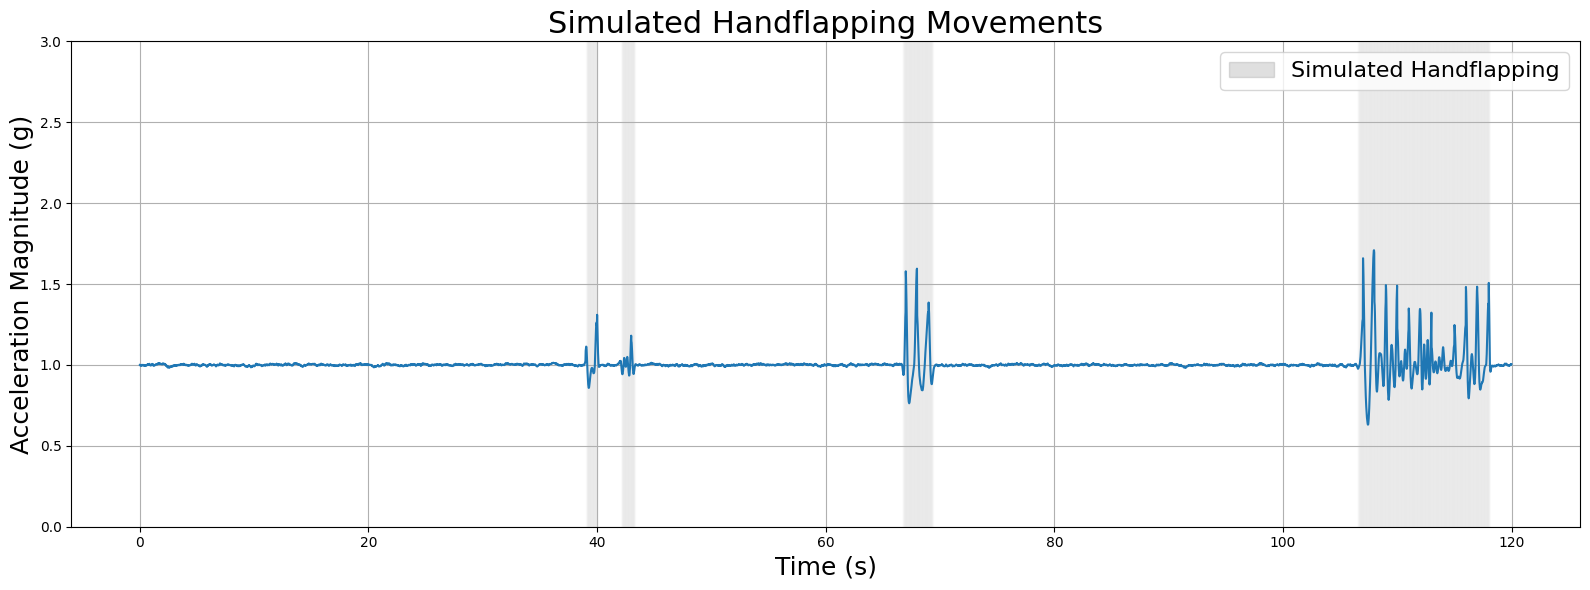

In [7067]:
from matplotlib.patches import Patch

fig, ax = plt.subplots(figsize=(16, 6))
ax.plot(time_array, final_signal)

ax.set_title("Simulated Handflapping Movements", fontsize=22)
ax.set_xlabel("Time (s)", fontsize=18)
ax.set_ylabel("Acceleration Magnitude (g)", fontsize=18)

ax.set_ylim(bottom=0, top=3)

# Add detected regions as shaded areas (gray bars)
for i in range(len(time_array) - 1):
    if detected[i]:
        ax.axvspan(time_array[i], time_array[i + 1], color='gray', alpha=0.01)

ax.legend(
    [Patch(color='gray', alpha=0.25)],
    ['Simulated Handflapping'],
    loc='upper right',
    prop={'size': 16})

ax.grid(True)
plt.tight_layout()
plt.show()

In [7068]:
# Ask the user if they want to export the data
from datetime import datetime

# export_data = input("Do you want to export the data and plot as files? (y/n): ").strip().lower()
export_data = 'y'

if export_data == 'y':
    # Create DataFrame with timestamp and accel.mag columns
    data = pd.DataFrame({
        'timestamp': time_array,
        'accel.mag': final_signal,
        "detected": detected
    })
    
    # Export to CSV
    export_directory = "data/simulated_data_visualization/"
    current_time = datetime.now().strftime("%Y%m%d_%H%M%S")
    csv_file_name = f"handflapping_simulated_data_{current_time}.csv"
    export_csv_path = export_directory + csv_file_name
    data.to_csv(export_csv_path, index=False)
    print(f"Data exported to {export_csv_path}")
    
    # Save the figure (even after plt.show())
    plot_file_name = f"handflapping_simulated_data_{current_time}_plot.png"
    export_plot_path = export_directory + plot_file_name
    fig.savefig(export_plot_path)
    print(f"Plot exported to {export_plot_path}")
else:
    print("Data export skipped.")

Data exported to data/simulated_data_visualization/handflapping_simulated_data_20250121_152152.csv
Plot exported to data/simulated_data_visualization/handflapping_simulated_data_20250121_152152_plot.png
